In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing as preproc
import seaborn as sns
from scipy.stats import binom

## Main Dataset Info

Dataset code: ITM08
Publisher: Central Statistics Office (CSO)
Dataset: Monthly nights spent at tourist accommodation establishments
Frequency: Monthly
Geographical coverage used: Ireland
Unit: Number of nights spent
Resident categories: Irish Resident / Non-Irish Resident
Period in downloaded dataset: January 2012 – December 2025
Role in project: Primary dataset

##

In [2]:
df_accommodation = pd.read_csv("Datasets/ITM08.20261004171056.csv")
df_accommodation.head(10)

,STATISTIC,Statistic Label,TLIST(M1),Month,C03880V04631,NUTS 3 Region,UNIT,VALUE
0,ITM08C01,Irish Resident,201201,2012 January,IE0,Ireland,Number of nights spent,806849.0
1,ITM08C01,Irish Resident,201202,2012 February,IE0,Ireland,Number of nights spent,957798.0
2,ITM08C01,Irish Resident,201203,2012 March,IE0,Ireland,Number of nights spent,1180245.0
3,ITM08C01,Irish Resident,201204,2012 April,IE0,Ireland,Number of nights spent,1282596.0
4,ITM08C01,Irish Resident,201205,2012 May,IE0,Ireland,Number of nights spent,1338550.0
5,ITM08C01,Irish Resident,201206,2012 June,IE0,Ireland,Number of nights spent,1536567.0
6,ITM08C01,Irish Resident,201207,2012 July,IE0,Ireland,Number of nights spent,1729441.0
7,ITM08C01,Irish Resident,201208,2012 August,IE0,Ireland,Number of nights spent,1910474.0
8,ITM08C01,Irish Resident,201209,2012 September,IE0,Ireland,Number of nights spent,1405849.0
9,ITM08C01,Irish Resident,201210,2012 October,IE0,Ireland,Number of nights spent,1256865.0


## Secondary Data set Info

Dataset code: TAM07
Publisher: Central Statistics Office (CSO)
Dataset: Passengers, Freight and Commercial Flights
Frequency: Monthly
Role in project: Secondary explanatory dataset

##

In [3]:
df_aviation = pd.read_csv("Datasets/TAM07.20261004175622.csv")
df_aviation.head()

,STATISTIC,Statistic Label,TLIST(M1),Month,C02935V03550,Airports in Ireland,C02191V04000,Country,C02354V02832,Direction,C02936V03551,Flight Type,UNIT,VALUE
0,TAM07C01,Passengers,202001,2020 January,EI0M,All main airports,-,All Countries,-,All directions,-,All flights,Thousand,2388.4
1,TAM07C01,Passengers,202001,2020 January,EI0M,All main airports,-,All Countries,-,All directions,1,Scheduled,Thousand,2365.5
2,TAM07C01,Passengers,202001,2020 January,EI0M,All main airports,-,All Countries,-,All directions,2,Unscheduled,Thousand,22.8
3,TAM07C01,Passengers,202001,2020 January,EI0M,All main airports,-,All Countries,3,Arrival,-,All flights,Thousand,1200.0
4,TAM07C01,Passengers,202001,2020 January,EI0M,All main airports,-,All Countries,3,Arrival,1,Scheduled,Thousand,1187.7


In [4]:
df_accommodation.isna().sum()

STATISTIC          0
Statistic Label    0
TLIST(M1)          0
Month              0
C03880V04631       0
NUTS 3 Region      0
UNIT               0
VALUE              0
dtype: int64

In [5]:
df_accommodation.shape

(336, 8)

## Findings

My main dataset has 336 rows/observations and 8 collums/features.

##


In [6]:
df_aviation.shape

(745524, 14)

## Findings

My secundary dataset has 745524 rows/observations and 14 collums/features.

##

In [7]:
df_aviation.isna().sum()

STATISTIC              0
Statistic Label        0
TLIST(M1)              0
Month                  0
C02935V03550           0
Airports in Ireland    0
C02191V04000           0
Country                0
C02354V02832           0
Direction              0
C02936V03551           0
Flight Type            0
UNIT                   0
VALUE                  0
dtype: int64

In [8]:
df_accommodation.duplicated().sum()

np.int64(0)

## Findings

Cheking for null values and understanding the shape of my two datasets, so far 0 null values.

##

In [9]:
for column in df_accommodation.columns:
    print(column, df_accommodation[column].nunique())

STATISTIC 2
Statistic Label 2
TLIST(M1) 168
Month 168
C03880V04631 1
NUTS 3 Region 1
UNIT 1
VALUE 331


In [10]:
df_accommodation["Statistic Label"].value_counts()

Statistic Label
Irish Resident        168
Non-Irish Resident    168
Name: count, dtype: int64

In [11]:
df_accommodation["C03880V04631"].value_counts()
df_accommodation["NUTS 3 Region"].value_counts()
df_accommodation["UNIT"].value_counts()

UNIT
Number of nights spent    336
Name: count, dtype: int64

## Findings

TLIST(M1) = 168 unique values
Month = 168 unique values
##

STATISTIC = 2
Statistic Label = 2
Corresponding to two classes Irish Resident/Non-Irish Resident
##

Constant Variables:
C03880V04631 = 1
NUTS 3 Region = 1
UNIT = 1
C03880V04631 → geographical code
NUTS 3 Region → Ireland
UNIT → Number of nights spent
That means these variables does not have variation within the dataset.

##


In [12]:
df_accommodation["VALUE"].describe()

count    3.360000e+02
mean     1.297874e+06
std      7.223619e+05
min      0.000000e+00
25%      8.511718e+05
50%      1.202406e+06
75%      1.666290e+06
max      4.630000e+06
Name: VALUE, dtype: float64

## Findings

This fiding is not very relevent statiscly since it shows the Resident and non-resident togherter. 

The data type is the expected one.

Next step is to see the describe for each class. 

##

In [13]:
df_accommodation.groupby("Statistic Label")["VALUE"].describe()

,count,mean,std,min,25%,50%,75%,max
Statistic Label,,,,,,,,
Irish Resident,168.0,1.298864e+06,677283.245890,0.0,942180.50,1187517.5,1525641.75,4630000.0
Non-Irish Resident,168.0,1.296885e+06,766826.938305,14206.0,715429.75,1255810.5,1776961.50,3353404.0


## Findings

Both resident categories contain 168 observations.

The overall means are very similar.

Non-Irish residents show a larger standard deviation than Irish
residents.
## Question:
Could this result from stronger seasonal variation?


The minimum for Irish residents is zero, whereas the minimum
for non-Irish residents is 14,206. 
## Question
Why zero and how to deal with this number.

Large differences exist between the minimum and maximum values
for both groups.

##

In [14]:
df_accommodation[
    df_accommodation["VALUE"] == 0
]

,STATISTIC,Statistic Label,TLIST(M1),Month,C03880V04631,NUTS 3 Region,UNIT,VALUE
99,ITM08C01,Irish Resident,202004,2020 April,IE0,Ireland,Number of nights spent,0.0
100,ITM08C01,Irish Resident,202005,2020 May,IE0,Ireland,Number of nights spent,0.0
101,ITM08C01,Irish Resident,202006,2020 June,IE0,Ireland,Number of nights spent,0.0


## Findings
A record of zero nights spent in accommodation by irish residents occured senquentially from April 2020 to June 2020.
## Probable cause
COVID-19 TIME / Additional information is needed.
## Data Preparation 
These values will initially be retained rather than modified at this moment. Because there is a pprobable reason for these values. 

In [15]:
df_accommodation.sort_values("VALUE").head(15)

,STATISTIC,Statistic Label,TLIST(M1),Month,C03880V04631,NUTS 3 Region,UNIT,VALUE
99,ITM08C01,Irish Resident,202004,2020 April,IE0,Ireland,Number of nights spent,0.0
100,ITM08C01,Irish Resident,202005,2020 May,IE0,Ireland,Number of nights spent,0.0
101,ITM08C01,Irish Resident,202006,2020 June,IE0,Ireland,Number of nights spent,0.0
267,ITM08C02,Non-Irish Resident,202004,2020 April,IE0,Ireland,Number of nights spent,14206.0
112,ITM08C01,Irish Resident,202105,2021 May,IE0,Ireland,Number of nights spent,28000.0
268,ITM08C02,Non-Irish Resident,202005,2020 May,IE0,Ireland,Number of nights spent,35398.0
111,ITM08C01,Irish Resident,202104,2021 April,IE0,Ireland,Number of nights spent,54000.0
278,ITM08C02,Non-Irish Resident,202103,2021 March,IE0,Ireland,Number of nights spent,60953.0
277,ITM08C02,Non-Irish Resident,202102,2021 February,IE0,Ireland,Number of nights spent,64024.0
279,ITM08C02,Non-Irish Resident,202104,2021 April,IE0,Ireland,Number of nights spent,69068.0


In [16]:
df_accommodation[
    df_accommodation["TLIST(M1)"].between(202001, 202012)
][
    ["Statistic Label", "TLIST(M1)", "Month", "VALUE"]
]

,Statistic Label,TLIST(M1),Month,VALUE
96,Irish Resident,202001,2020 January,688000.0
97,Irish Resident,202002,2020 February,851000.0
98,Irish Resident,202003,2020 March,710000.0
99,Irish Resident,202004,2020 April,0.0
100,Irish Resident,202005,2020 May,0.0
101,Irish Resident,202006,2020 June,0.0
102,Irish Resident,202007,2020 July,2349000.0
103,Irish Resident,202008,2020 August,4630000.0
104,Irish Resident,202009,2020 September,1339000.0
105,Irish Resident,202010,2020 October,398000.0


In [17]:
# Remover as colunas geográficas e a unidade
df_accommodation = df_accommodation.drop(
    columns=["C03880V04631", "NUTS 3 Region", "UNIT"]
)

# Converter o código do mês para uma data
df_accommodation["Month"] = pd.to_datetime(
    df_accommodation["TLIST(M1)"].astype(str),
    format="%Y%m"
)

# Criar uma linha por mês e uma coluna por categoria de residência
df_accommodation = (
    df_accommodation
    .pivot(
        index="Month",
        columns="Statistic Label",
        values="VALUE"
    )
    .rename(columns={
        "Irish Resident": "Irish_Resident_Nights",
        "Non-Irish Resident": "Non_Irish_Resident_Nights"
    })
    .rename_axis(columns=None)
    .reset_index()
    .sort_values("Month")
    .reset_index(drop=True)
)

df_accommodation.head()

,Month,Irish_Resident_Nights,Non_Irish_Resident_Nights
0,2012-01-01,806849.0,333708.0
1,2012-02-01,957798.0,424743.0
2,2012-03-01,1180245.0,716280.0
3,2012-04-01,1282596.0,851229.0
4,2012-05-01,1338550.0,1074729.0


In [18]:
print("Dimensões:", df_accommodation.shape)
print("Meses duplicados:", df_accommodation["Month"].duplicated().sum())
print("Valores ausentes:\n", df_accommodation.isna().sum())

Dimensões: (168, 3)
Meses duplicados: 0
Valores ausentes:
 Month                        0
Irish_Resident_Nights        0
Non_Irish_Resident_Nights    0
dtype: int64


In [19]:
df_accommodation_price_index = pd.read_csv("Datasets/CPM18.20261008T141058.csv")
df_accommodation_price_index.head(10)

,Statistic Label,Month,Detailed Sub Indices,UNIT,VALUE
0,Consumer Price Index,2012 January,Accommodation services,Base Dec 2023=100,54.7
1,Consumer Price Index,2012 February,Accommodation services,Base Dec 2023=100,55.4
2,Consumer Price Index,2012 March,Accommodation services,Base Dec 2023=100,56.9
3,Consumer Price Index,2012 April,Accommodation services,Base Dec 2023=100,58.1
4,Consumer Price Index,2012 May,Accommodation services,Base Dec 2023=100,59.2
5,Consumer Price Index,2012 June,Accommodation services,Base Dec 2023=100,62.2
6,Consumer Price Index,2012 July,Accommodation services,Base Dec 2023=100,63.8
7,Consumer Price Index,2012 August,Accommodation services,Base Dec 2023=100,64.2
8,Consumer Price Index,2012 September,Accommodation services,Base Dec 2023=100,62.4
9,Consumer Price Index,2012 October,Accommodation services,Base Dec 2023=100,59.8


In [20]:
df_accommodation.describe()

,Month,Irish_Resident_Nights,Non_Irish_Resident_Nights
count,168,1.680000e+02,1.680000e+02
mean,2018-12-16 05:42:51.428571,1.298864e+06,1.296885e+06
min,2012-01-01 00:00:00,0.000000e+00,1.420600e+04
25%,2015-06-23 12:00:00,9.421805e+05,7.154298e+05
50%,2018-12-16 12:00:00,1.187518e+06,1.255810e+06
75%,2022-06-08 12:00:00,1.525642e+06,1.776962e+06
max,2025-12-01 00:00:00,4.630000e+06,3.353404e+06
std,NaN,6.772832e+05,7.668269e+05


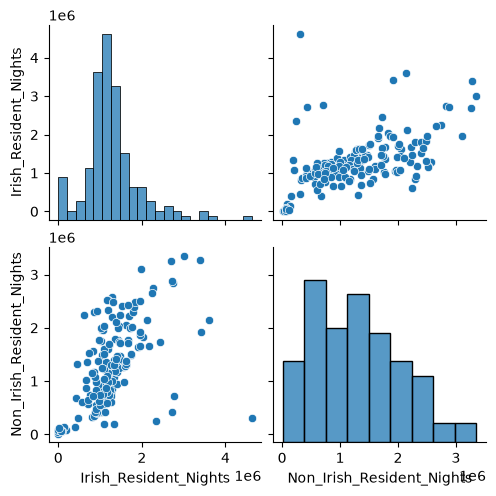

In [24]:
sns.pairplot(df_accommodation)

<Axes: >

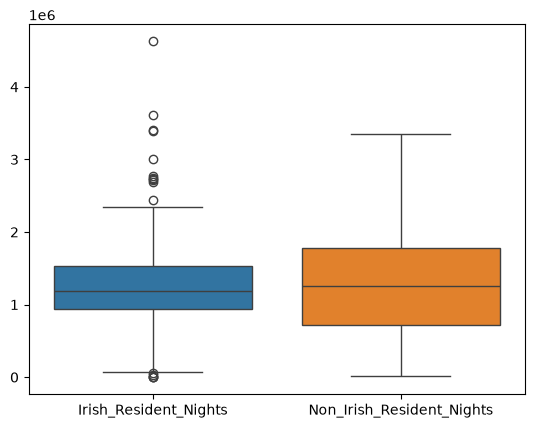

In [26]:
sns.boxplot(df_accommodation)

<Axes: ylabel='Density'>

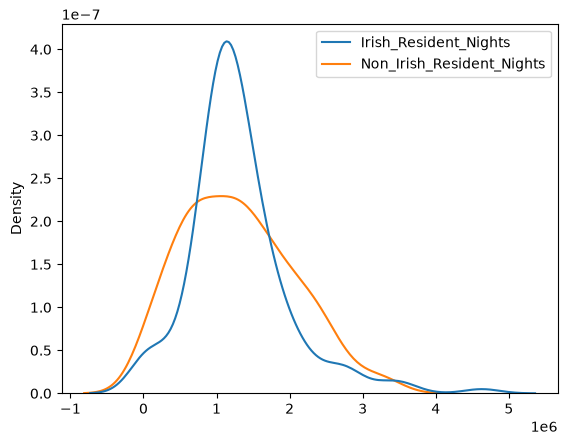

In [32]:
sns.kdeplot(df_accommodation)

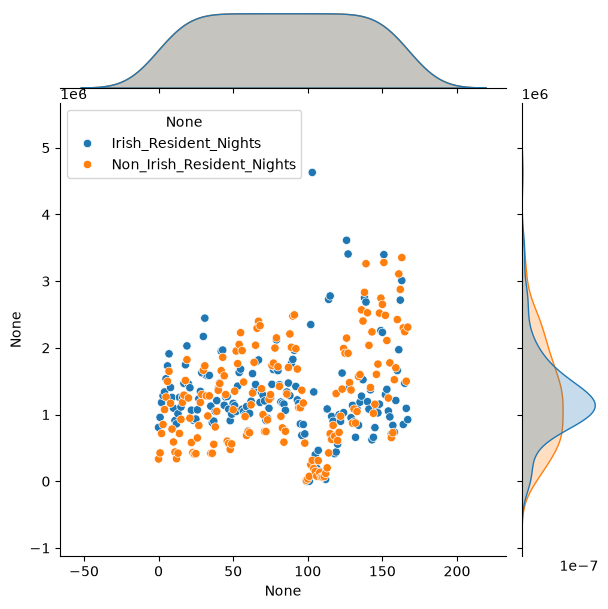

In [33]:
sns.jointplot(df_accommodation)

<Axes: >

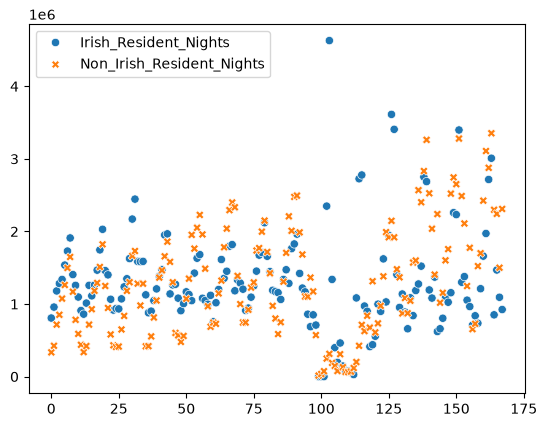

In [34]:
sns.scatterplot(df_accommodation)

<Axes: >

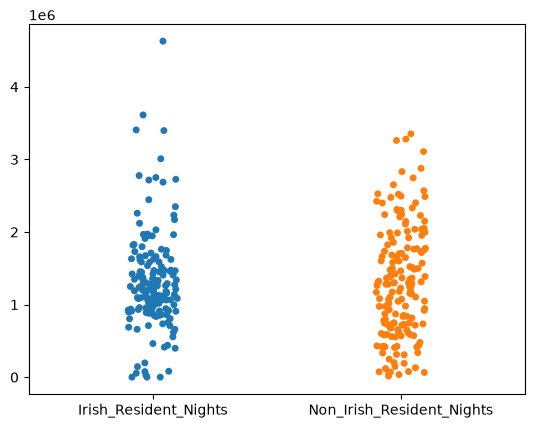

In [35]:
sns.stripplot(df_accommodation)

<Axes: ylabel='Proportion'>

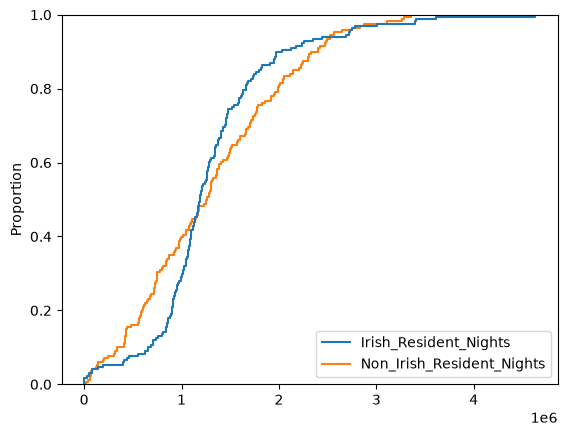

In [42]:
sns.ecdfplot(df_accommodation)

<Axes: >

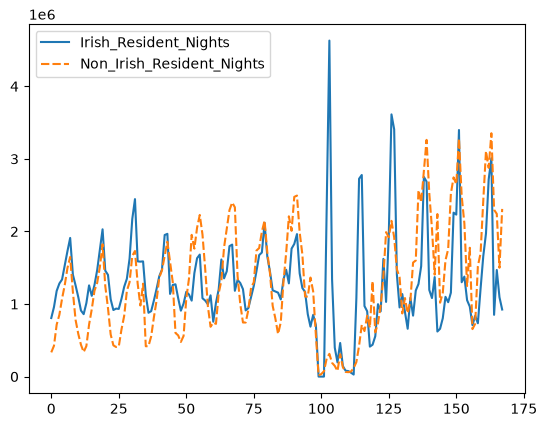

In [44]:
sns.lineplot(df_accommodation)

<Axes: xlabel='Irish_Resident_Nights', ylabel='Non_Irish_Resident_Nights'>

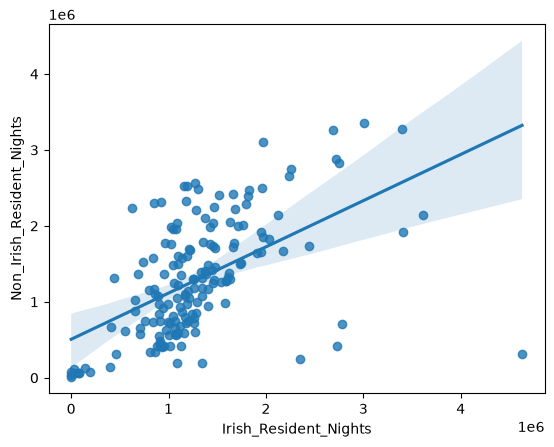

In [53]:
sns.regplot(data=df_accommodation, x='Irish_Resident_Nights', y='Non_Irish_Resident_Nights')

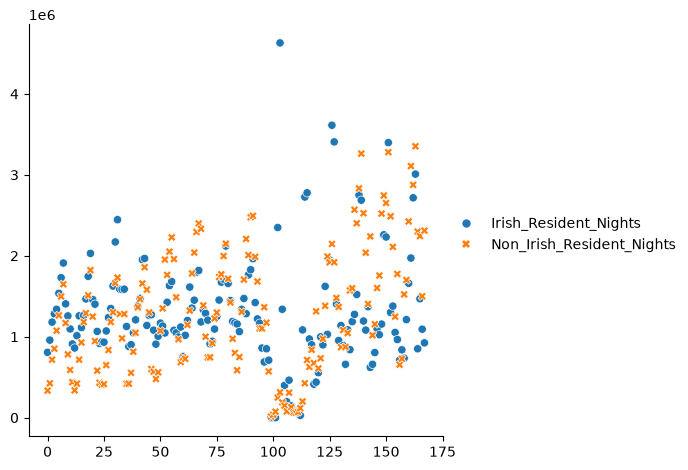

In [54]:
sns.relplot(df_accommodation)

<Axes: xlabel='Irish_Resident_Nights', ylabel='Non_Irish_Resident_Nights'>

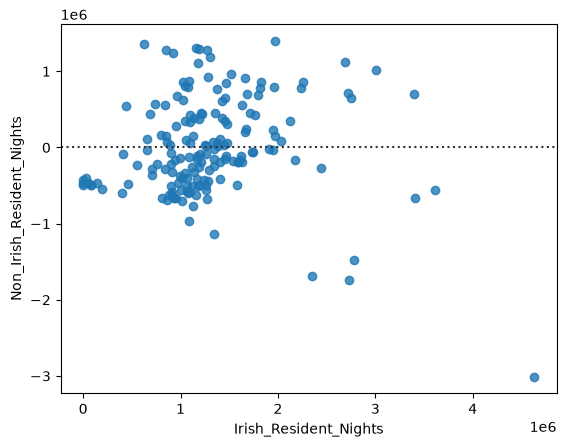

In [56]:
sns.residplot(data=df_accommodation, x='Irish_Resident_Nights', y='Non_Irish_Resident_Nights')